# A-side activation isotropy for Keller vs MuP

This notebook backs the A-factor scaling decision with captured inputs to `lora_A`. The data file is produced by replaying the saved optimizer snapshot, extracting the current A-update rowspace, running eval batches through the checkpointed model, and measuring how much activation RMS lands in that update rowspace.

Source command for the current CSV:

```bash
CUDA_VISIBLE_DEVICES=0 python -u scripts/analysis/muon_activation_isotropy_probe.py --ckpt-dir /mnt/ceph/users/nghosh/lora_snapshots/chord_tight_r64_k3_snapshot_blackwell/task_0/step_4000 --num-batches 4 --batch-size 1 --device cuda
```

Interpretation: Keller predicts ratio near 1 for A. The full worst-case endpoint is `sqrt(d_in / r)`. The measured best A correction is `1 / measured_ratio`. If that correction is fit as `(r / d_in)^p`, Keller is `p=0` and MuP is `p=0.5`.

Paper context checked alongside this probe:

- LoRA+ says equal A/B learning rates are asymptotically inefficient and motivates making the B-side rate larger than the A-side rate; it does not decide the Keller-vs-MuP compression correction for A.
- MuA says rank scaling depends on initialization and adapter multiplier. Under this repo's default PEFT init, random A and zero B with effective multiplier 1, the single-LR optimum should move roughly like inverse square root rank; that is separate from the per-factor subspace anisotropy tested here.
- BaLoRA says factor balance is a product-preserving conditioning choice. It supports periodically balancing the LoRA factors, but it does not remove the need to choose the physical A/B update radii before the projection.

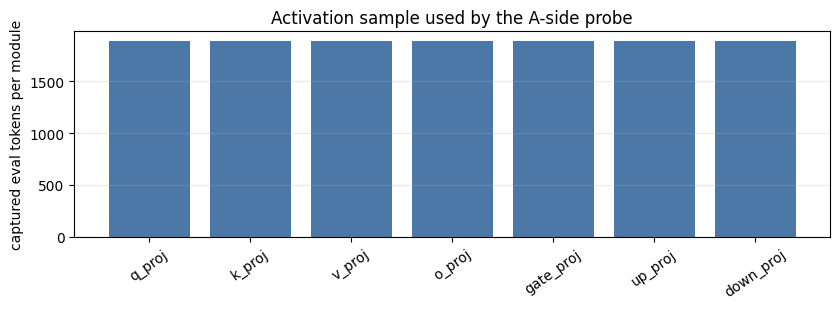

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'lora_playground').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('could not find project root from current working directory')

ROOT = find_project_root(Path.cwd().resolve())

ROWS_CSV = ROOT / 'notebooks/snapshot_analysis/_data/muon_activation_isotropy_rows.csv'
if not ROWS_CSV.exists():
    raise FileNotFoundError(f'missing {ROWS_CSV}; run scripts/analysis/muon_activation_isotropy_probe.py first')

rows = pd.read_csv(ROWS_CSV)
rows['module_label'] = rows['module_kind'].str.replace('[default]', '', regex=False)
rows['p_fit'] = np.log(rows['best_alpha']) / np.log(rows['r'] / rows['d_in'])
rows['quarter_power_alpha'] = (rows['r'] / rows['d_in']) ** 0.25

module_order = [
    'q_proj', 'k_proj', 'v_proj', 'o_proj',
    'gate_proj', 'up_proj', 'down_proj',
]
present_order = [m for m in module_order if m in set(rows['module_label'])]

summary = (
    rows.groupby(['module_label', 'd_in', 'r'], as_index=False)
    .agg(
        n_modules=('pair', 'count'),
        tokens=('tokens', 'median'),
        actual_ratio=('actual_ratio', 'median'),
        worst_ratio=('worst_ratio', 'median'),
        best_alpha=('best_alpha', 'median'),
        mup_alpha=('mup_alpha', 'median'),
        quarter_power_alpha=('quarter_power_alpha', 'median'),
        energy_concentration=('energy_concentration_vs_isotropic', 'median'),
        actual_over_worst=('actual_over_worst', 'median'),
        p_fit=('p_fit', 'median'),
    )
)
summary['module_label'] = pd.Categorical(summary['module_label'], present_order, ordered=True)
summary = summary.sort_values('module_label').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.bar(summary['module_label'].astype(str), summary['tokens'], color='#4C78A8')
ax.set_ylabel('captured eval tokens per module')
ax.set_title('Activation sample used by the A-side probe')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

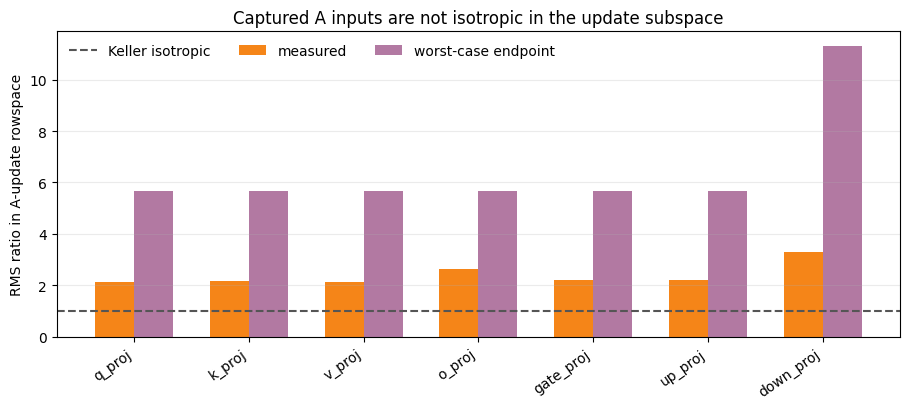

In [2]:
x = np.arange(len(summary))
width = 0.34

fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.axhline(1.0, color='#555555', linestyle='--', linewidth=1.5, label='Keller isotropic')
ax.bar(x - width / 2, summary['actual_ratio'], width, color='#F58518', label='measured')
ax.bar(x + width / 2, summary['worst_ratio'], width, color='#B279A2', label='worst-case endpoint')
ax.set_xticks(x)
ax.set_xticklabels(summary['module_label'].astype(str), rotation=35, ha='right')
ax.set_ylabel('RMS ratio in A-update rowspace')
ax.set_title('Captured A inputs are not isotropic in the update subspace')
ax.legend(frameon=False, ncols=3, loc='upper left')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

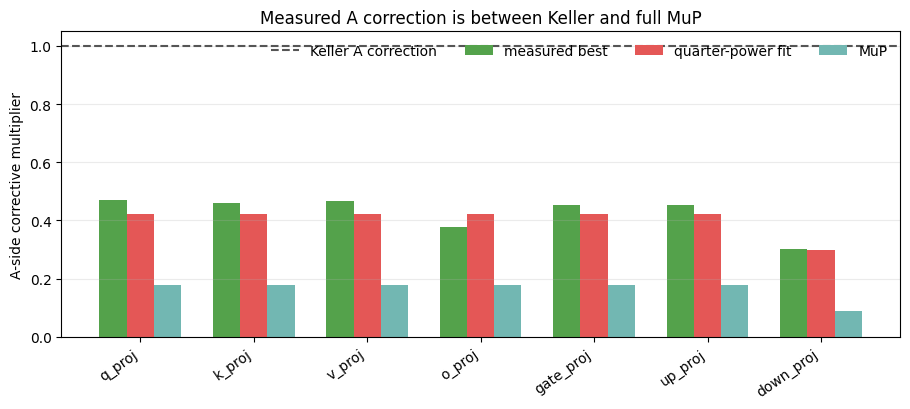

In [3]:
width = 0.24

fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.axhline(1.0, color='#555555', linestyle='--', linewidth=1.5, label='Keller A correction')
ax.bar(x - width, summary['best_alpha'], width, color='#54A24B', label='measured best')
ax.bar(x, summary['quarter_power_alpha'], width, color='#E45756', label='quarter-power fit')
ax.bar(x + width, summary['mup_alpha'], width, color='#72B7B2', label='MuP')
ax.set_xticks(x)
ax.set_xticklabels(summary['module_label'].astype(str), rotation=35, ha='right')
ax.set_ylabel('A-side corrective multiplier')
ax.set_title('Measured A correction is between Keller and full MuP')
ax.legend(frameon=False, ncols=4, loc='upper right')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

/tmp/ipykernel_3751370/2794083423.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=present_order, patch_artist=True, showfliers=False)


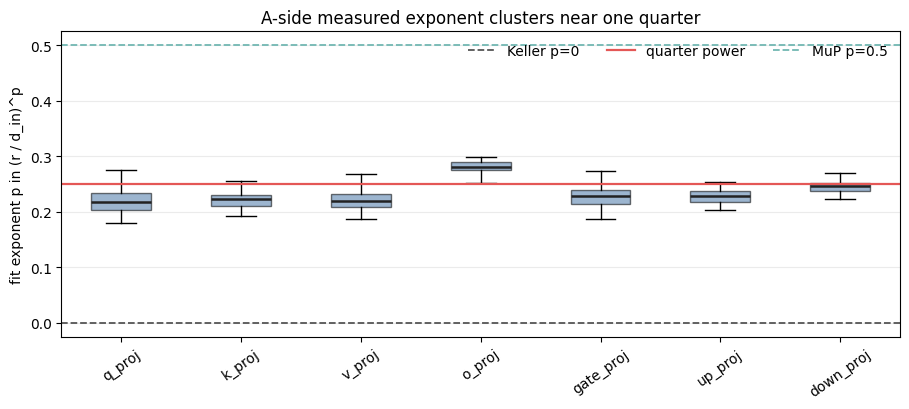

In [4]:
box_data = [rows.loc[rows['module_label'] == label, 'p_fit'].to_numpy() for label in present_order]

fig, ax = plt.subplots(figsize=(9.2, 4.2))
bp = ax.boxplot(box_data, labels=present_order, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('#4C78A8')
    patch.set_alpha(0.55)
for median in bp['medians']:
    median.set_color('#222222')
    median.set_linewidth(1.8)
ax.axhline(0.0, color='#555555', linestyle='--', linewidth=1.3, label='Keller p=0')
ax.axhline(0.25, color='#E45756', linestyle='-', linewidth=1.6, label='quarter power')
ax.axhline(0.5, color='#72B7B2', linestyle='--', linewidth=1.3, label='MuP p=0.5')
ax.set_ylabel('fit exponent p in (r / d_in)^p')
ax.set_title('A-side measured exponent clusters near one quarter')
ax.tick_params(axis='x', rotation=35)
ax.legend(frameon=False, ncols=3, loc='upper right')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

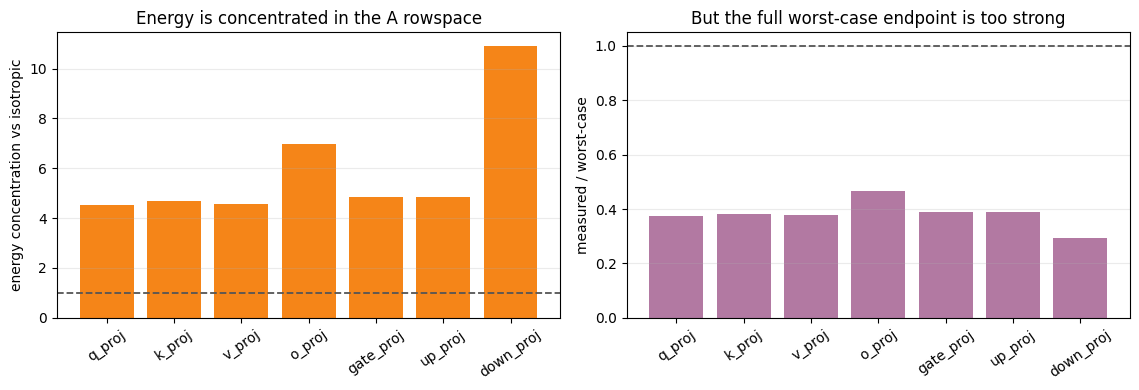

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharex=True)
axes[0].bar(summary['module_label'].astype(str), summary['energy_concentration'], color='#F58518')
axes[0].axhline(1.0, color='#555555', linestyle='--', linewidth=1.3)
axes[0].set_ylabel('energy concentration vs isotropic')
axes[0].set_title('Energy is concentrated in the A rowspace')
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(summary['module_label'].astype(str), summary['actual_over_worst'], color='#B279A2')
axes[1].axhline(1.0, color='#555555', linestyle='--', linewidth=1.3)
axes[1].set_ylabel('measured / worst-case')
axes[1].set_title('But the full worst-case endpoint is too strong')
axes[1].grid(axis='y', alpha=0.25)

for ax in axes:
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()

## Saved-step timeline

The same activation-rowspace probe was run at all saved checkpoints: steps 0, 50, 200, 500, 1000, 2000, and 4000. Step 0 is near isotropic, but by step 50 the A-update rowspace is already activation-concentrated and remains stable through the rest of training.


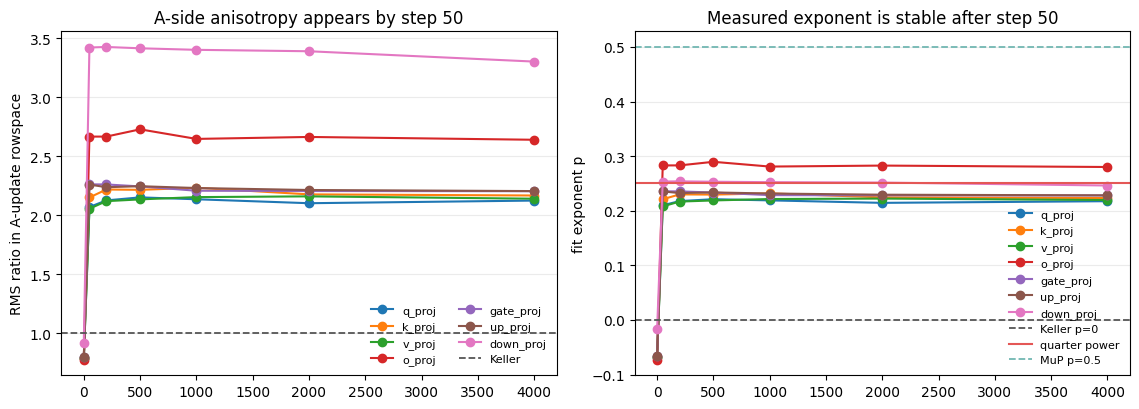

In [6]:
timeline_csv = ROOT / 'notebooks/snapshot_analysis/_data/muon_activation_isotropy_timeline_summary.csv'
if not timeline_csv.exists():
    raise FileNotFoundError(f'missing {timeline_csv}; run the per-step activation probe first')
timeline = pd.read_csv(timeline_csv)
timeline['module_label'] = timeline['module_label'].astype(str)
timeline['module_label'] = pd.Categorical(timeline['module_label'], present_order, ordered=True)
timeline = timeline.sort_values(['module_label', 'step'])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharex=True)
for label in present_order:
    sub = timeline[timeline['module_label'] == label]
    axes[0].plot(sub['step'], sub['actual_ratio'], marker='o', label=label)
    axes[1].plot(sub['step'], sub['p_fit'], marker='o', label=label)
axes[0].axhline(1.0, color='#555555', linestyle='--', linewidth=1.3, label='Keller')
axes[0].set_ylabel('RMS ratio in A-update rowspace')
axes[0].set_title('A-side anisotropy appears by step 50')
axes[0].grid(axis='y', alpha=0.25)
axes[1].axhline(0.0, color='#555555', linestyle='--', linewidth=1.3, label='Keller p=0')
axes[1].axhline(0.25, color='#E45756', linestyle='-', linewidth=1.5, label='quarter power')
axes[1].axhline(0.5, color='#72B7B2', linestyle='--', linewidth=1.3, label='MuP p=0.5')
axes[1].set_ylabel('fit exponent p')
axes[1].set_title('Measured exponent is stable after step 50')
axes[1].grid(axis='y', alpha=0.25)
axes[0].legend(frameon=False, fontsize=8, ncols=2)
axes[1].legend(frameon=False, fontsize=8, ncols=1, loc='lower right')
plt.tight_layout()


In [7]:
timeline_table = timeline.pivot(index='step', columns='module_label', values='actual_ratio')
timeline_table = timeline_table[[c for c in present_order if c in timeline_table.columns]]
print('Measured RMS ratio by saved step')
display(timeline_table.round(3))
print('Median fitted exponent p by saved step')
rows_timeline = pd.read_csv(ROOT / 'notebooks/snapshot_analysis/_data/muon_activation_isotropy_timeline_rows.csv')
display(rows_timeline.groupby('step')['p_fit'].median().round(3).to_frame('median_p'))


Measured RMS ratio by saved step


module_label,q_proj,k_proj,v_proj,o_proj,gate_proj,up_proj,down_proj
step,,,,,,,
0,0.791,0.791,0.791,0.778,0.797,0.797,0.920
50,2.071,2.152,2.057,2.668,2.263,2.261,3.423
200,2.127,2.219,2.120,2.668,2.262,2.239,3.427
500,2.153,2.217,2.136,2.729,2.245,2.247,3.416
1000,2.137,2.234,2.155,2.648,2.209,2.232,3.403
2000,2.103,2.178,2.161,2.665,2.206,2.215,3.391
4000,2.125,2.168,2.141,2.641,2.205,2.206,3.303


Median fitted exponent p by saved step


,median_p
step,
0,-0.064
50,0.232
200,0.234
500,0.236
1000,0.237
2000,0.232
4000,0.232
